In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


In [9]:
symbol = 'I'
train_label = 5
train_end_date = '2025-01-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'I',
 'contract_multiplier': 100,
 'price_tick': 0.5,
 'margin_rate': 0.11,
 'fee': 0.0001,
 'fee_way': 'rate',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '铁矿石'}

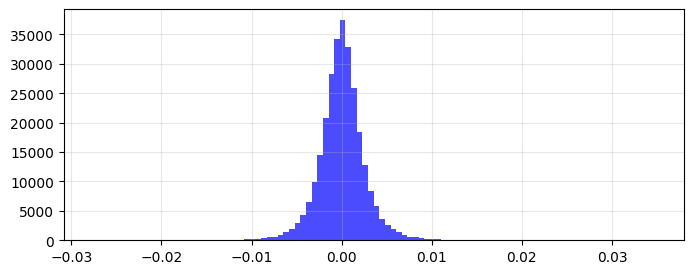

2025-01-01_I_5


In [10]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [11]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(RB_|I_|SM_|SF_|HC_|SS_|J_|JM_|WR_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['FAC_Depth_Reversal_downmean', 'FAC_Depth_Reversal_upmean', 'pred_ret']
特征分布性过滤：
筛选之前因子数量：1873， 筛选之后因子数量：1792

特征重要性过滤： 300 200 	待筛因子个数 1792
无向因子有效个数： 1017 有向因子有效个数： 834
  选择有向特征 223 个，重要性范围: 3931.00 - 140.00
  选择无向特征 146 个，重要性范围: 4086.00 - 206.00

单因子sharpe过滤： 0 sp范围-13.2608 ~ 11.3541   待筛因子个数 369

特征相关性性过滤： 300     待筛因子个数 369
  选择特征 300 个, 特征最大相关性0.8976009100564525

已挑选日频开盘因子数量： 6 ['day_first4redcorr', 'day_jump', 'day_first3power', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_jump', 'day_first3power', 'day_first4greencorr', 'day_first10rev']

排除指定因子后，剩余特征 299 个


(215, 0, 53, 31)

正在从 /mnt/Data/writable/liaoyuyang/factor/I/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (283262, 1877)
训练集时间范围: 2021-02-02 09:11:00 至 2024-12-31 14:49:00
[200]	valid_0's rmse: 0.996084
[400]	valid_0's rmse: 0.996769


<Figure size 1000x600 with 0 Axes>

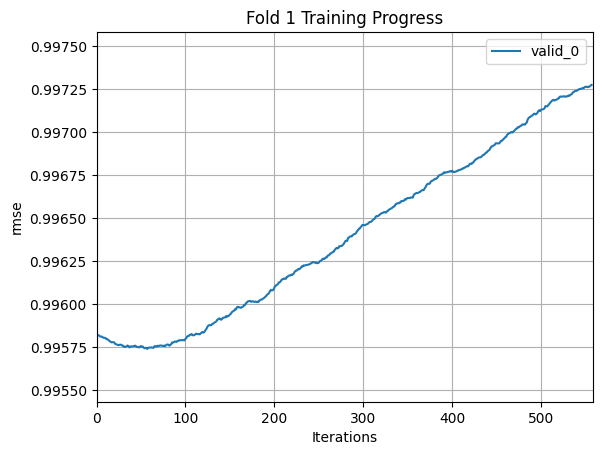

{'train_rmse': np.float64(0.998925266896186), 'val_rmse': np.float64(0.9999842905674672), 'best_iteration': 58}
test_corr: 0.0251
[200]	valid_0's rmse: 0.995038
[400]	valid_0's rmse: 0.994595
[600]	valid_0's rmse: 0.994401
[800]	valid_0's rmse: 0.994314
[1000]	valid_0's rmse: 0.994326
[1200]	valid_0's rmse: 0.99436
[1400]	valid_0's rmse: 0.99444


<Figure size 1000x600 with 0 Axes>

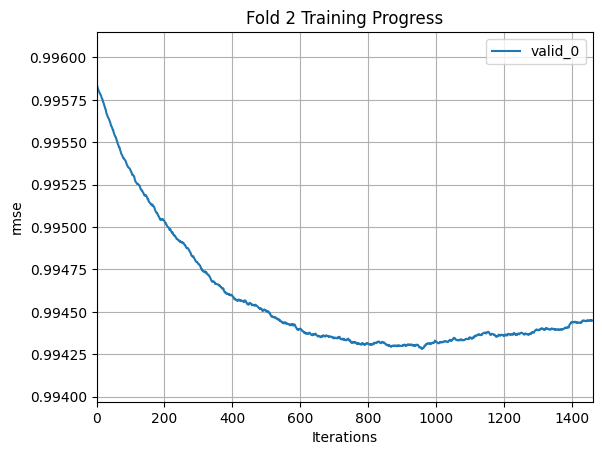

{'train_rmse': np.float64(0.9884652035172855), 'val_rmse': np.float64(0.9984934504546882), 'best_iteration': 960}
test_corr: 0.0444
[200]	valid_0's rmse: 0.995174
[400]	valid_0's rmse: 0.994903
[600]	valid_0's rmse: 0.99475
[800]	valid_0's rmse: 0.994664
[1000]	valid_0's rmse: 0.994558
[1200]	valid_0's rmse: 0.994474
[1400]	valid_0's rmse: 0.994427
[1600]	valid_0's rmse: 0.994368
[1800]	valid_0's rmse: 0.994359
[2000]	valid_0's rmse: 0.994346
[2200]	valid_0's rmse: 0.994359
[2400]	valid_0's rmse: 0.994325
[2600]	valid_0's rmse: 0.994322
[2800]	valid_0's rmse: 0.994332


<Figure size 1000x600 with 0 Axes>

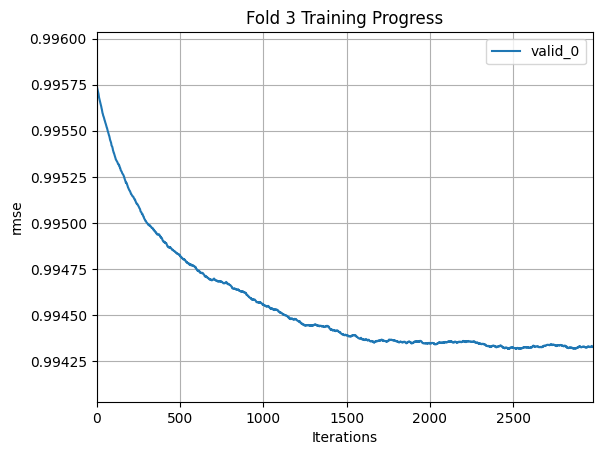

{'train_rmse': np.float64(0.9758552731182668), 'val_rmse': np.float64(0.9984934597241425), 'best_iteration': 2476}
test_corr: 0.0302
[200]	valid_0's rmse: 0.995062
[400]	valid_0's rmse: 0.994733
[600]	valid_0's rmse: 0.994559
[800]	valid_0's rmse: 0.994403
[1000]	valid_0's rmse: 0.994293
[1200]	valid_0's rmse: 0.994199
[1400]	valid_0's rmse: 0.994135
[1600]	valid_0's rmse: 0.994083
[1800]	valid_0's rmse: 0.994045
[2000]	valid_0's rmse: 0.994008
[2200]	valid_0's rmse: 0.993981
[2400]	valid_0's rmse: 0.99397
[2600]	valid_0's rmse: 0.993957
[2800]	valid_0's rmse: 0.993949
[3000]	valid_0's rmse: 0.993942
[3200]	valid_0's rmse: 0.993938
[3400]	valid_0's rmse: 0.993941
[3600]	valid_0's rmse: 0.993957


<Figure size 1000x600 with 0 Axes>

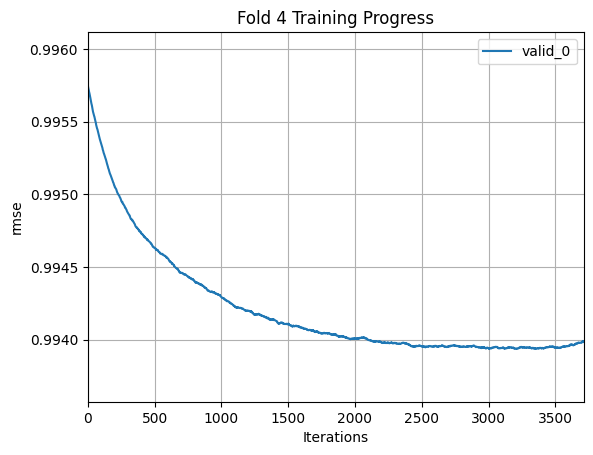

{'train_rmse': np.float64(0.9708393690547329), 'val_rmse': np.float64(0.9980211928399197), 'best_iteration': 3213}
test_corr: 0.0283
[200]	valid_0's rmse: 0.995292
[400]	valid_0's rmse: 0.99512
[600]	valid_0's rmse: 0.995027
[800]	valid_0's rmse: 0.994997
[1000]	valid_0's rmse: 0.995019
[1200]	valid_0's rmse: 0.995047


<Figure size 1000x600 with 0 Axes>

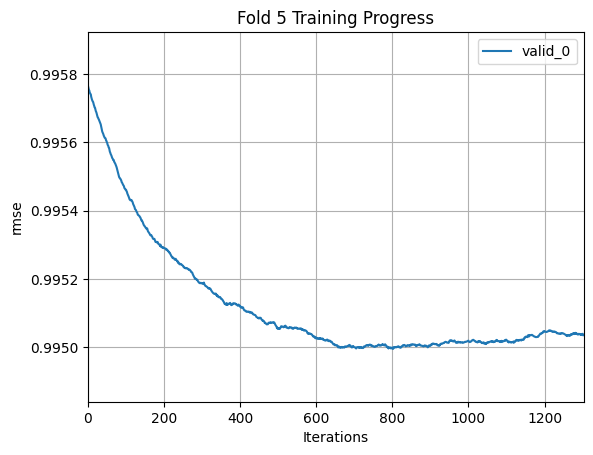

{'train_rmse': np.float64(0.9899070347785844), 'val_rmse': np.float64(0.9992373126857851), 'best_iteration': 803}
test_corr: 0.0358


In [12]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [13]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/I_pred5_2025-01-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [14]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 82_530 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [15]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
使用的交易价格 tick6t60avg


计算持仓表:   0%|          | 0/96617 [00:00<?, ?it/s]

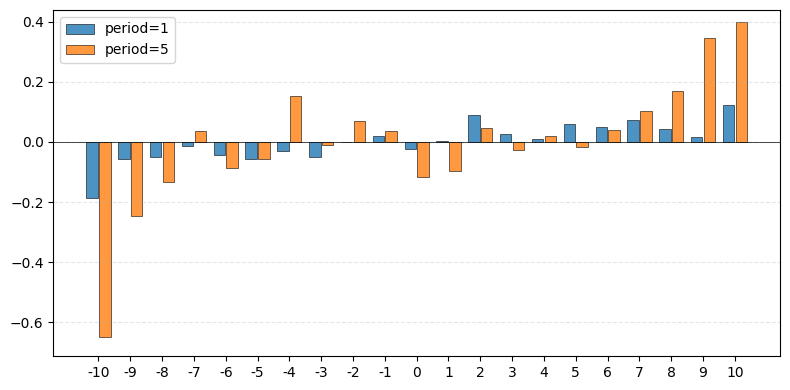

In [16]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-23:00"], g=21)

In [17]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,20306
空头(-1) 数量,19185
空仓(0) 数量,57128
多头占比,21.02%
空头占比,19.86%
空仓占比,59.13%
交易日数量,284
总收益(非年化%),466.40
总交易次数（开平算一次）,3334
日均交易次数（开平算一次）,11.74


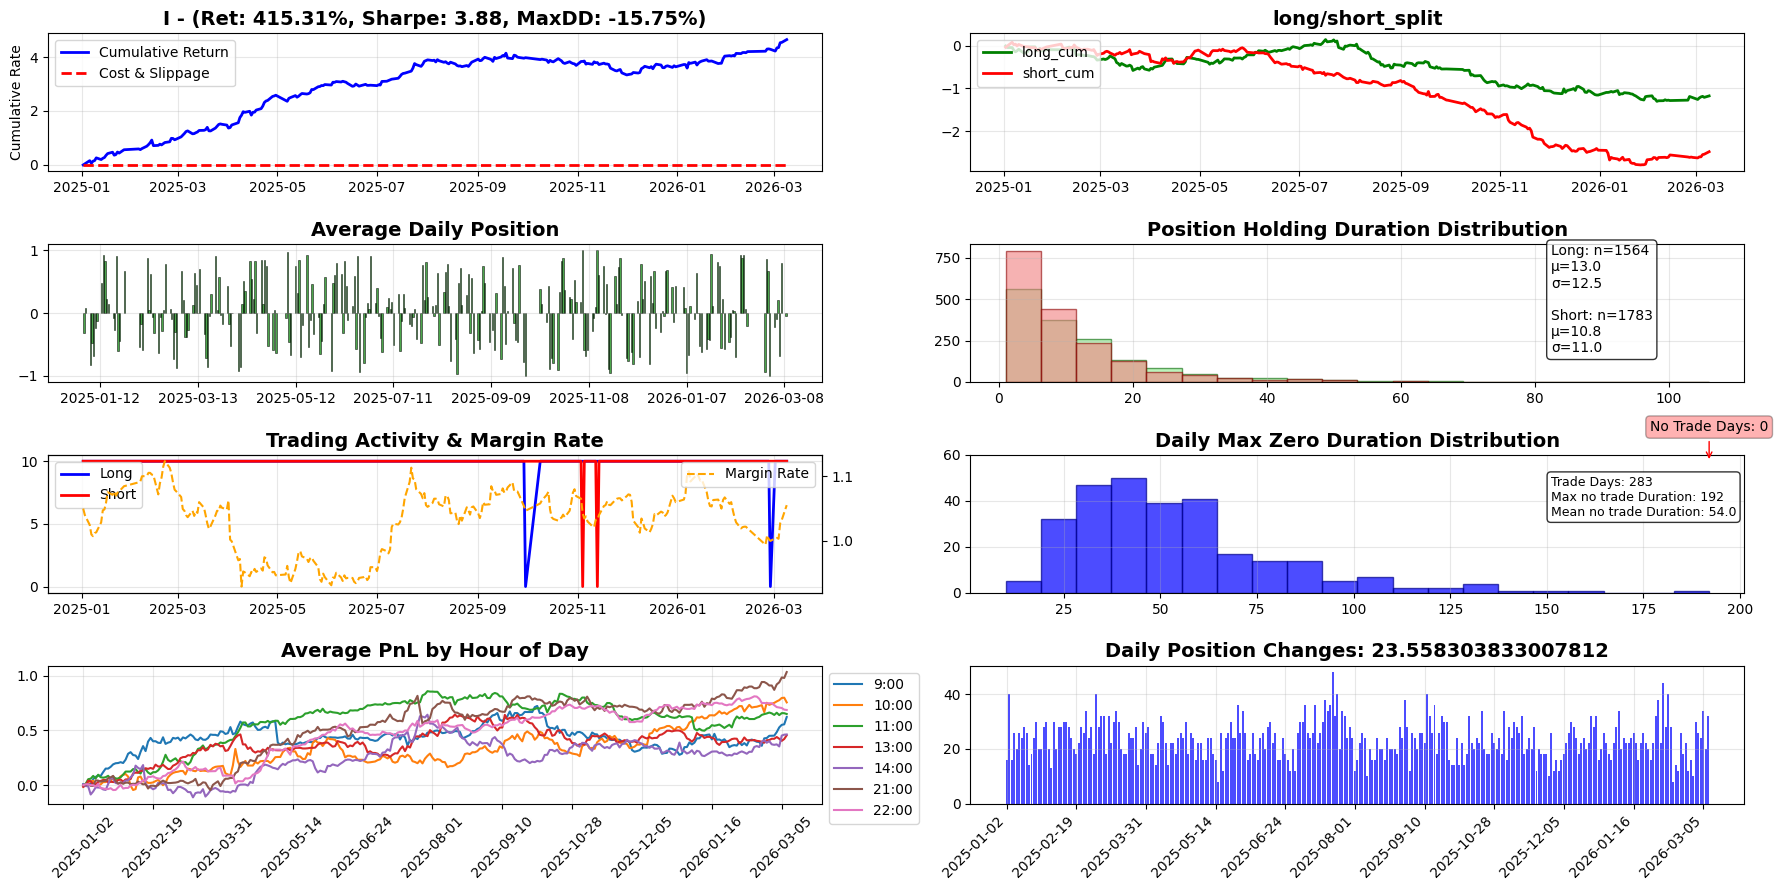

In [18]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [19]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: I
📅 总交易日数: 283
📊 总数据点: 102729
🎯 使用导航按钮或输入页码进行浏览


In [20]:
bv.plot_yearly_eval(merged_data)